## HOTEL DISCOUNT OPTIMIZATION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestRegressor


In [3]:
df = pd.read_csv(r"D:\Data science\CAPSTONE PROJECT\Hotel-Management-Optimization\hotels_data.csv")

In [4]:
df.head()

,Snapshot ID,Snapshot Date,Checkin Date,Days,Original Price,Discount Price,Discount Code,Available Rooms,Hotel Name,Hotel Stars
0,1,7/17/2015 0:00,8/12/2015 0:00,5,1178,1040,1,6,Best Western Plus Seaport Inn Downtown,3
1,1,7/17/2015 0:00,8/19/2015 0:00,5,1113,982,1,8,Best Western Plus Seaport Inn Downtown,3
2,1,7/17/2015 0:00,8/13/2015 0:00,5,4370,4240,1,3,The Peninsula New York,5
3,1,7/17/2015 0:00,7/26/2015 0:00,5,1739,1667,1,18,Eventi Hotel a Kimpton Hotel,4
4,1,7/17/2015 0:00,8/12/2015 0:00,5,1739,1672,1,3,Eventi Hotel a Kimpton Hotel,4


### Cleaning & Feature Engginering

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187848 entries, 0 to 187847
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Snapshot ID      187848 non-null  int64 
 1   Snapshot Date    187848 non-null  object
 2   Checkin Date     187848 non-null  object
 3   Days             187848 non-null  int64 
 4   Original Price   187848 non-null  int64 
 5   Discount Price   187848 non-null  int64 
 6   Discount Code    187848 non-null  int64 
 7   Available Rooms  187848 non-null  int64 
 8   Hotel Name       187848 non-null  object
 9   Hotel Stars      187848 non-null  int64 
dtypes: int64(7), object(3)
memory usage: 14.3+ MB


In [6]:
df.isnull().sum()

Snapshot ID        0
Snapshot Date      0
Checkin Date       0
Days               0
Original Price     0
Discount Price     0
Discount Code      0
Available Rooms    0
Hotel Name         0
Hotel Stars        0
dtype: int64

In [7]:
# Remove missing and placeholder values
df = df.replace(-1, np.nan)
df = df.dropna()

# Create discount percentage feature
df["Discount_Percent"] = ((df["Original Price"] - df["Discount Price"]) / df["Original Price"]) * 100

# Convert dates to proper type
df["Snapshot Date"] = pd.to_datetime(df["Snapshot Date"])
df["Checkin Date"] = pd.to_datetime(df["Checkin Date"])

# Days until check-in
df["Days_Until_Checkin"] = (df["Checkin Date"] - df["Snapshot Date"]).dt.days


### Price Elasticity

In [8]:
# Predict Available Rooms based on pricing and discount.

# Feature selection
features = ["Original Price", "Discount Price", "Discount_Percent", "Hotel Stars", "Days", "Days_Until_Checkin"]
X = df[features]
y = df["Available Rooms"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (important for regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = RandomForestRegressor(random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Performance
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score: 0.6445977901472464
RMSE: 33.67039512133761


### Clustering

In [ ]:
# Clustering Hotels

cluster_features = df[["Hotel Stars", "Original Price", "Discount_Percent"]]

scaler2 = StandardScaler()
cluster_scaled = scaler2.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(cluster_scaled)

df.groupby("Cluster")[["Hotel Stars", "Original Price", "Discount_Percent"]].mean()


,Hotel Stars,Original Price,Discount_Percent
Cluster,,,
0,4.918498,3266.241058,5.738183
1,3.560107,1480.799239,7.188291
2,4.064863,1695.323956,22.057354


### Visualize clusters

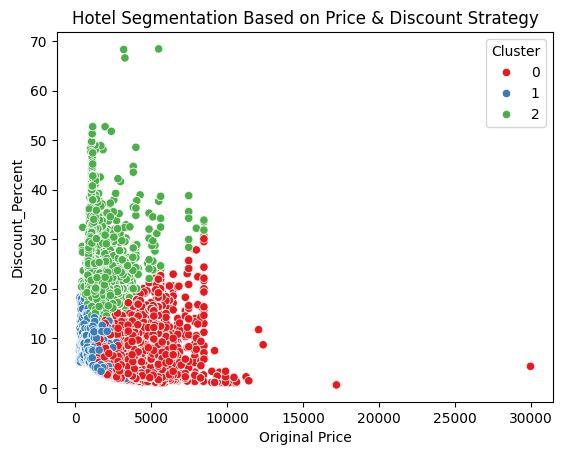

In [10]:
sns.scatterplot(
    x=df["Original Price"],
    y=df["Discount_Percent"],
    hue=df["Cluster"],
    palette="Set1"
)
plt.title("Hotel Segmentation Based on Price & Discount Strategy")
plt.show()
